## Librerias

In [ ]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [ ]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [ ]:
# Cuantos partidos se jugaron?
mundial["match_no"].sum()

np.int64(2080)

In [ ]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
mundial.info()
mundial.describe()
mundial.columns
mundial.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 59 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   match_no                         64 non-null     int64  
 1   day_of_week                      64 non-null     object 
 2   date                             64 non-null     object 
 3   hour                             64 non-null     object 
 4   venue                            64 non-null     object 
 5   referee                          64 non-null     object 
 6   group                            64 non-null     object 
 7   1                                64 non-null     object 
 8   2                                64 non-null     object 
 9   attendance                       64 non-null     int64  
 10  1_xg                             64 non-null     float64
 11  2_xg                             64 non-null     float64
 12  1_poss                  

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361


## Analisis

### Primera Parte

In [ ]:
# Cuantas selecciones participaron?
equipos = pd.concat ([mundial["1"], mundial ["2"]])
cantidad_equipos = equipos.unique()
CANTIDAD_de_equipos = len(cantidad_equipos)
print (f"La cantidad de selecciones que participaron son: {CANTIDAD_de_equipos}")

La cantidad de selecciones que participaron son: 32


In [ ]:
# Cuantas fases tiene el mundial?
# Completar
fases = len(mundial["group"].unique())
print (f"La cantidad de fases que tiene son: {fases}")

La cantidad de fases que tiene son: 13


In [ ]:
# Cual fue la "attendance" promedio por partido?
# Completar
attendance = mundial["attendance"].mean()
print (f"La attendance promedio por partido es: {attendance}")

La attendance promedio por partido es: 53191.4375


In [ ]:
# Cual fue el partido con mas diferencia de goles?
# Completar
goles_equipo1 = mundial["1_goals"]
goles_equipo2 = mundial["2_goals"]
diferencia_goles = (goles_equipo1 - goles_equipo2)
indice_max = diferencia_goles.abs().idxmax()
tabla_partido = mundial.iloc[indice_max]
print(f"El partido con mas diferecia de goles es: {tabla_partido["1"]} - {tabla_partido["2"]} con un resultado de: {tabla_partido["1_goals"]} - {tabla_partido["2_goals"]}")

El partido con mas diferecia de goles es: SPAIN - COSTA RICA con un resultado de: 7 - 0


In [ ]:
# Cual es la selección que mas penales metió?
# Completar
penales_local = mundial.groupby('1')['1_panelties_scored'].sum()
penales_visitante = mundial.groupby('2')['2_panelties_scored'].sum()

total_penales = penales_local.add(penales_visitante)

seleccion_maxima = total_penales.idxmax()
cantidad_penales = total_penales.max()

print(f"La selección que más penales metió es: {seleccion_maxima} con {cantidad_penales} penales.")

La selección que más penales metió es: ARGENTINA con 4 penales.


In [ ]:
# Cual es la selección que mas penales le hicieron?
# Completar

penales_local = mundial.groupby('1')['2_panelties_scored'].sum()
penales_visitante = mundial.groupby('2')['1_panelties_scored'].sum()

total_penales = penales_local.add(penales_visitante)

seleccion_maxima = total_penales.idxmax()
cantidad_penales = total_penales.max()

print(f"La selección que más penales le hicieron es: {seleccion_maxima} con {cantidad_penales} penales.")

La selección que más penales le hicieron es: FRANCE con 3 penales.


### Segunda Parte

In [ ]:
equipo : str = "ARGENTINA"

In [ ]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

equipo : str = "ARGENTINA"

filtroLocal : pd.Series = mundial["1"] == equipo

partidos_de_equipo_local = mundial[filtroLocal]
print(partidos_de_equipo_local[["match_no", "1", "2"]])

    match_no          1             2
4          5  ARGENTINA  SAUDI ARABIA
23        24  ARGENTINA        MEXICO
49        50  ARGENTINA     AUSTRALIA
60        61  ARGENTINA       CROATIA
63        64  ARGENTINA        FRANCE


In [ ]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

equipo : str = "ARGENTINA"

filtroVisitante : pd.Series = mundial["2"] == equipo

partidos_de_equipo_visitante = mundial[filtroVisitante]
print(partidos_de_equipo_visitante[["match_no", "1", "2"]])

    match_no            1          2
38        39       POLAND  ARGENTINA
57        58  NETHERLANDS  ARGENTINA


In [ ]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = mundial[filtroLocal | filtroVisitante]
print(partidos[["match_no", "1", "2"]])


    match_no            1             2
4          5    ARGENTINA  SAUDI ARABIA
23        24    ARGENTINA        MEXICO
38        39       POLAND     ARGENTINA
49        50    ARGENTINA     AUSTRALIA
57        58  NETHERLANDS     ARGENTINA
60        61    ARGENTINA       CROATIA
63        64    ARGENTINA        FRANCE


In [ ]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar

goles_local = mundial[filtroLocal]["1_goals"].sum()
goles_visitante = mundial[filtroVisitante]["2_goals"].sum()
goles : int = goles_local + goles_visitante
print(f"El equipo ARGENTINA hizo {goles} goles en total.")

El equipo ARGENTINA hizo 15 goles en total.


In [ ]:
# Cuantos goles hizo el equipo en promedio
# Completar

goles_local = mundial[filtroLocal]["1_goals"]
goles_visitante = mundial[filtroVisitante]["2_goals"]
goles = pd.concat([goles_local, goles_visitante])
promedio = goles.mean()
print(f"El equipo ARGENTINA hizo un promedio de {promedio} respecto los goles.")

El equipo ARGENTINA hizo un promedio de 2.142857142857143 respecto los goles.


In [ ]:
# Cuantos partidos gano el equipo
# Completar

equipo : str = "ARGENTINA"

partidos_local = mundial[mundial["1"] == equipo]
ganados_local = partidos_local[partidos_local["1_goals"] > partidos_local["2_goals"]]

partidos_visitante = mundial[mundial["2"] == equipo]
ganados_visitante = partidos_visitante[partidos_visitante["2_goals"] > partidos_visitante["1_goals"]]

ganados : int = len(ganados_local) + len(ganados_visitante)

print(f"El equipo ARGENTINA ganó {ganados} partidos.")

El equipo ARGENTINA ganó 4 partidos.


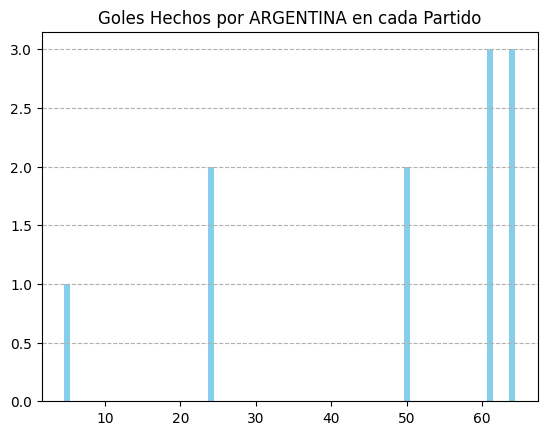

In [ ]:
fig, ax = plt.subplots()
partidos = mundial[mundial["1"] == "ARGENTINA"]
equipo_goals = partidos["1_goals"]

ax.bar(partidos['match_no'], equipo_goals, color='skyblue')
ax.set_title(f'Goles Hechos por {equipo} en cada Partido')
plt.grid(axis='y', linestyle='--')
plt.show()

### Tercera Parte

In [ ]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

equipos = pd.concat([mundial["1"], mundial["2"]])
goles = equipos.count().sum()
print(goles)

128


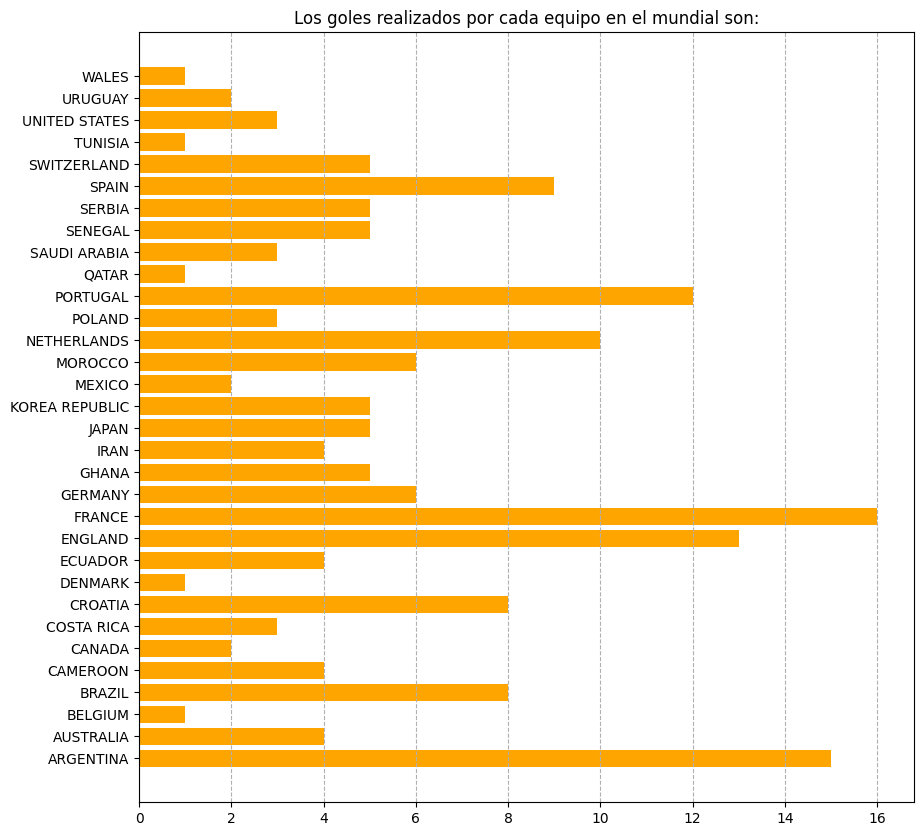

In [ ]:
# Graficar los goles por equipo en todo el mundial
goles_por_equipo = mundial.groupby('1')['1_goals'].sum().add(mundial.groupby('2')['2_goals'].sum())
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(goles_por_equipo.index, goles_por_equipo.values, color='orange')
ax.set_title("Los goles realizados por cada equipo en el mundial son:")
ax.grid(axis = 'x', linestyle = '--')
plt.show()
# Completar

In [ ]:
# Cual es el equipo que hizo mas goles en el mundial?
equipos = pd.concat((mundial["1"], ( mundial["2"])))
equipo_superior = equipos.value_counts().idxmax()
print (f"El equipo con mas goles en el mundial es: {equipo_superior}")
# Completar

El equipo con mas goles en el mundial es: FRANCE


In [ ]:
# Por cada partido, cual fue la diferencia de goles?
# Completar

mundial['diferencia_goles'] = mundial['1_goals'] - mundial['2_goals']

for i in range(len(mundial)):
    match_numero = mundial['match_no'].iloc[i]
    goles_diferencia = mundial['diferencia_goles'].iloc[i]
    print(f"En el partido {match_numero}, la diferencia de goles fue de: {goles_diferencia}")

En el partido 1, la diferencia de goles fue de: -2
En el partido 2, la diferencia de goles fue de: 4
En el partido 3, la diferencia de goles fue de: -2
En el partido 4, la diferencia de goles fue de: 0
En el partido 5, la diferencia de goles fue de: -1
En el partido 6, la diferencia de goles fue de: 0
En el partido 7, la diferencia de goles fue de: 0
En el partido 8, la diferencia de goles fue de: 3
En el partido 9, la diferencia de goles fue de: 0
En el partido 10, la diferencia de goles fue de: -1
En el partido 11, la diferencia de goles fue de: 7
En el partido 12, la diferencia de goles fue de: 1
En el partido 13, la diferencia de goles fue de: 1
En el partido 14, la diferencia de goles fue de: 0
En el partido 15, la diferencia de goles fue de: 1
En el partido 16, la diferencia de goles fue de: 2
En el partido 17, la diferencia de goles fue de: -2
En el partido 18, la diferencia de goles fue de: -2
En el partido 19, la diferencia de goles fue de: 0
En el partido 20, la diferencia de

In [ ]:
# Por cada partido, cual fue el equipo que gano?
# Completar

mundial['diferencia_goles'] = mundial['1_goals'] - mundial['2_goals']

for i in range(len(mundial)):
    match_numero = mundial['match_no'].iloc[i]
    goles_diferencia = mundial['diferencia_goles'].iloc[i]

    if (goles_diferencia < 0):
      print(f"El equipo ganador es: Equipo 2")
    elif (goles_diferencia > 0):
      print(f"El equipo ganador es: Equipo 1")
    else:
      print(f"El equipo ganador es: Empate")

El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 2
El equipo ganador es: Empate
El equipo ganador es: Equipo 2
El equipo ganador es: Empate
El equipo ganador es: Empate
El equipo ganador es: Equipo 1
El equipo ganador es: Empate
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Empate
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 2
El equipo ganador es: Empate
El equipo ganador es: Empate
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 1
El equipo ganador es: Empate
El equipo ganador es: Empate
El equipo ganador es: Equipo 2
El equipo ganador es: Equipo 1
El equipo ganador es: Equipo 1
El equipo ganador es: Equi

In [ ]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar

fases = mundial['group'].unique()

for fase in fases:
    partidos = mundial[mundial['group'] == fase]

    goles_1 = partidos.groupby('1')['1_goals'].sum()
    goles_2 = partidos.groupby('2')['2_goals'].sum()

    todos_los_goles = goles_1.add(goles_2, fill_value=0)

    equipo_ganador = todos_los_goles.idxmax()
    print(f"En la fase {fase} el equipo con mas goles fue: {equipo_ganador}")

En la fase Group A el equipo con mas goles fue: NETHERLANDS
En la fase Group B el equipo con mas goles fue: ENGLAND
En la fase Group C el equipo con mas goles fue: ARGENTINA
En la fase Group D el equipo con mas goles fue: FRANCE
En la fase Group F el equipo con mas goles fue: CROATIA
En la fase Group E el equipo con mas goles fue: SPAIN
En la fase Group G el equipo con mas goles fue: SERBIA
En la fase Group H el equipo con mas goles fue: PORTUGAL
En la fase Round of 16 el equipo con mas goles fue: PORTUGAL
En la fase Quarter-final el equipo con mas goles fue: ARGENTINA
En la fase Semi-Final el equipo con mas goles fue: ARGENTINA
En la fase Play-off for third place el equipo con mas goles fue: CROATIA
En la fase Final el equipo con mas goles fue: ARGENTINA


### Tercera Parte

En la fase Group A se hicieron un total de 15 goles.
En la fase Group B se hicieron un total de 16 goles.
En la fase Group C se hicieron un total de 12 goles.
En la fase Group D se hicieron un total de 11 goles.
En la fase Group F se hicieron un total de 11 goles.
En la fase Group E se hicieron un total de 22 goles.
En la fase Group G se hicieron un total de 16 goles.
En la fase Group H se hicieron un total de 17 goles.
En la fase Round of 16 se hicieron un total de 28 goles.
En la fase Quarter-final se hicieron un total de 10 goles.
En la fase Semi-Final se hicieron un total de 5 goles.
En la fase Play-off for third place se hicieron un total de 3 goles.
En la fase Final se hicieron un total de 6 goles.


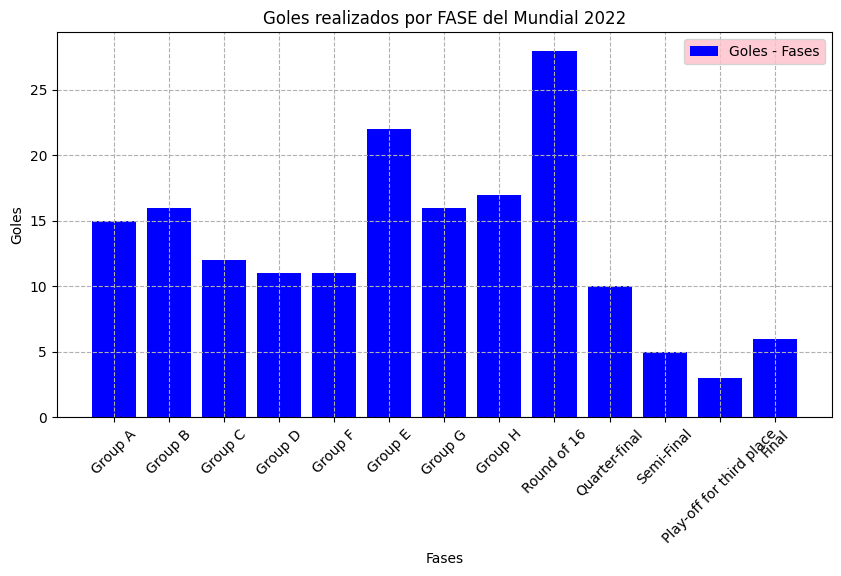

In [ ]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar

nombre_fases = []
cantidad_goles = []

fases = mundial['group'].unique()
for fase in fases:
  goles = mundial[mundial['group'] == fase]
  suma_goles = goles['1_goals'].sum()
  suma_goles_2 = goles['2_goals'].sum()
  goles_totales = suma_goles + suma_goles_2
  print(f"En la fase {fase} se hicieron un total de {goles_totales} goles.")

  nombre_fases.append(fase)
  cantidad_goles.append(goles_totales)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar (nombre_fases, cantidad_goles, color = 'blue', label = 'Goles - Fases')
plt.xticks(rotation=45)
ax.set_title ("Goles realizados por FASE del Mundial 2022")
ax.set_xlabel ("Fases")
ax.set_ylabel ("Goles")
ax.legend(facecolor = 'pink')
ax.grid(linestyle = '--')
plt.show()